In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

In [102]:
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits


In [20]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-02-10 14:42:19--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv.1’

candidate_1.csv.1   100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-02-10 14:42:20 (68.8 MB/s) - ‘candidate_1.csv.1’ saved [4479/4479]



In [2]:
nearby = at.Table.read('NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References
bytes16,bytes10,bytes11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,bytes53
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,--,--,--,--,--,--,(14)(15)(99)
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,--,--,--,--,--,--,(1)(2)(95)(176)
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267)
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267)
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267)
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267)
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267)
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267)
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267)


In [25]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_2.csv

--2026-02-10 14:51:36--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1504 (1.5K) [text/plain]
Saving to: ‘candidate_2.csv’

candidate_2.csv     100%[===================>]   1.47K  --.-KB/s    in 0s      

2026-02-10 14:51:36 (28.5 MB/s) - ‘candidate_2.csv’ saved [1504/1504]



In [32]:
candi_wavelet = pd.read_csv('candidate_2.csv')
candi_wavelet

,Unnamed: 0,source_id,dec,ra,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,...,bp_g,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error
0,351,3.694700e+18,-1.778258,185.911563,-1.856842,-1.587827,0.650409,0.346072,0.364194,0.334638,...,0.275600,0.861231,620.163923,1.358747,18.982700,352.756637,11.813906,18.121470,453.085400,6.235875
1,2048,3.694690e+18,-1.820663,186.065248,-2.359703,-1.639413,0.252295,0.144184,-0.340064,0.134653,...,0.167730,0.554670,2694.421252,40.112147,17.279932,1692.710689,88.120814,16.725262,1639.318047,57.702462
2,2703,3.694700e+18,-1.757881,185.976780,-1.839716,-1.458793,0.231413,0.136968,-0.028396,0.123043,...,0.483509,1.140743,3294.261366,2.935275,17.377480,1547.260737,7.914949,16.236736,2570.830282,8.658995
3,2709,3.694700e+18,-1.769745,185.950939,-1.794859,-1.570040,1.559956,0.718909,-0.148532,0.819093,...,0.166574,0.714191,207.757801,1.046456,20.061047,130.658285,6.078974,19.346855,146.563649,6.314567
4,2846,3.694690e+18,-1.785465,186.016646,-1.818842,-1.377200,2.051190,1.076516,1.905339,1.091935,...,0.013329,0.666397,126.422894,0.868855,20.447130,91.559412,5.825455,19.780733,98.282253,6.180286


In [131]:
## I am not too convinced that you can detect those candidates from the wavelet paper, I'm confused there's so few members?
## worth a shot ig


## Some known dwarfs galaxies 

In [58]:
# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
!wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

--2026-02-11 12:44:52--  https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt
Resolving content.cld.iop.org (content.cld.iop.org)... 108.157.194.98, 108.157.194.74, 108.157.194.31, ...
Connecting to content.cld.iop.org (content.cld.iop.org)|108.157.194.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9578 (9.4K) [text/plain]
Saving to: ‘apjab7eb9t2_mrt.txt.1’

apjab7eb9t2_mrt.txt 100%[===================>]   9.35K  --.-KB/s    in 0s      

2026-02-11 12:44:52 (237 MB/s) - ‘apjab7eb9t2_mrt.txt.1’ saved [9578/9578]



In [3]:
dwarfs =ascii.read('apjab7eb9t2_mrt.txt')

In [55]:
!cat apjab7eb9t2_mrt.txt

Title: Milky Way Satellite Census - I. The Observational Selection Function 
       for Milky Way Satellites in DES Y3 and Pan-STARRS DR1 
Authors: Drlica-Wagner A., Bechtol K., Mau S., McNanna M., Nadler E.O., 
         Pace A.B., Li T.S., Pieres A., Rozo E., Simon J.D., Walker A.R., 
         Wechsler R.H., Abbott T.M.C., Allam S., Annis J., Bertin E., 
         Brooks D., Burke D.L., Rosell A.C., Kind M.C., Carretero J., 
         Costanzi M., da Costa L.N., Vicente J.D., Desai S., Diehl H.T., 
         Doel P., Eifler T.F., Everett S., Flaugher B., Frieman J., 
         Garcia-Bellido J., Gaztanaga E., Gruen D., Gruendl R.A., Gschwend J.,
         Gutierrez G., Honscheid K., James D.J., Krause E., Kuehn K., 
         Kuropatkin N., Lahav O., Maia M.A.G., Marshall J.L., Melchior P., 
         Menanteau F., Miquel R., Palmese A., Plazas A.A., Sanchez E., 
         Scarpine V., Schubnell M., Serrano S., Sevilla-Noarbe I., 
         Smith M., Suchyta E., Tarle G. 
Table: Confirmed and 

In [39]:
dwarfs[dwarfs['Class']==4]


Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Antlia II,--,4,143.8868,-36.7673,20.6,76.2,--,0.38,132,2301,-9.03,1
Aquarius II,PS1,4,338.4813,-9.3274,20.2,5.1,--,0.39,108,125,-4.4,2
Bootes I,PS1,4,210.02,14.5135,19.1,9.97,--,0.3,66,160,-6.02,3
Bootes II,PS1,4,209.5141,12.8553,18.1,3.17,--,0.25,42,33,-2.94,3
Bootes III,PS1,4,209.3,26.8,18.4,30.0,--,0.5,47,289,-5.75,4
Canes Venatici I,PS1,4,202.0091,33.5521,21.7,7.12,--,0.44,218,338,-8.8,3
Canes Venatici II,PS1,4,194.2927,34.3226,21.0,1.52,--,0.4,160,55,-5.17,3
Carina,--,4,100.4065,-50.9593,20.1,10.1,--,0.36,105,248,-9.43,3


In [85]:
fornaxid = np.where(dwarfs['Name']=='Bootes I')[0][0]
dwarfs[fornaxid]

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Bootes I,PS1,4,210.02,14.5135,19.1,9.97,--,0.3,66,160,-6.02,3


In [55]:
## 

### SAME CUT AS WAVELET + ruwe

In [56]:
# probably relevant https://academic.oup.com/mnras/article/518/3/3746/6825500?login=true

In [87]:
### square select

##Reduce the amount of features we get

## large parallax: closer
## We want smaller parallax but still good measurement ?


center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 25 # lets ignore this cut

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, source_id FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND parallax - parallax_error * 3 < 0.0  \
AND ruwe < 1.4 )".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax, source_id FROM gaiadr3.gaia_source WHERE (ra < 213.02 AND ra > 207.02 AND dec <  17.5135 AND dec > 11.5135 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND parallax - parallax_error * 3 < 0.0  AND ruwe < 1.4 )
INFO: Query finished. [astroquery.utils.tap.core]
7.422205209732056
17290


Text(0, 0.5, 'Dec')

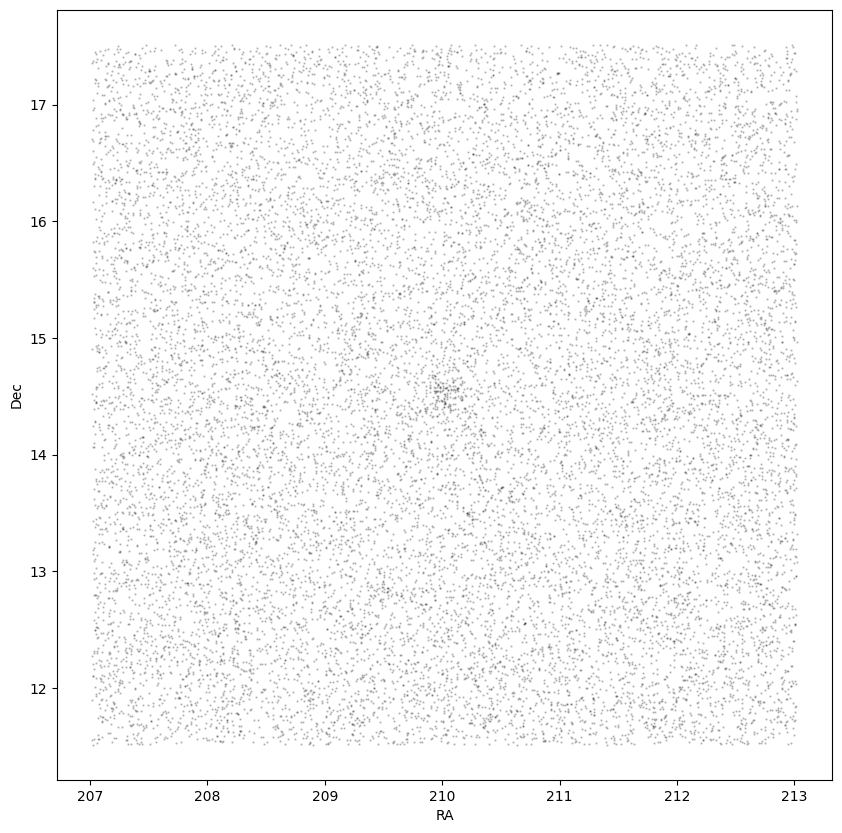

In [88]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

## A Cut that uses parallax small 

### Sven says there is Bayesian stuff to improve parallax estimates; maybe we hsould look into this

In [141]:
### square select

##Reduce the amount of features we get

## large parallax: closer
## We want smaller parallax but still good measurement ?


center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 25 # lets ignore this cut
max_parallax = 1 ## Problem is I'm not sure this is ok?
## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND parallax  < {}  \
AND ruwe < 1.4 )".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep, max_parallax)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT source_id, ra, dec, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 213.02 AND ra > 207.02 AND dec <  17.5135 AND dec > 11.5135 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND parallax  < 1  AND ruwe < 1.4 )
INFO: Query finished. [astroquery.utils.tap.core]
3.142486095428467
17669


In [90]:
#r

Text(0, 0.5, 'Dec')

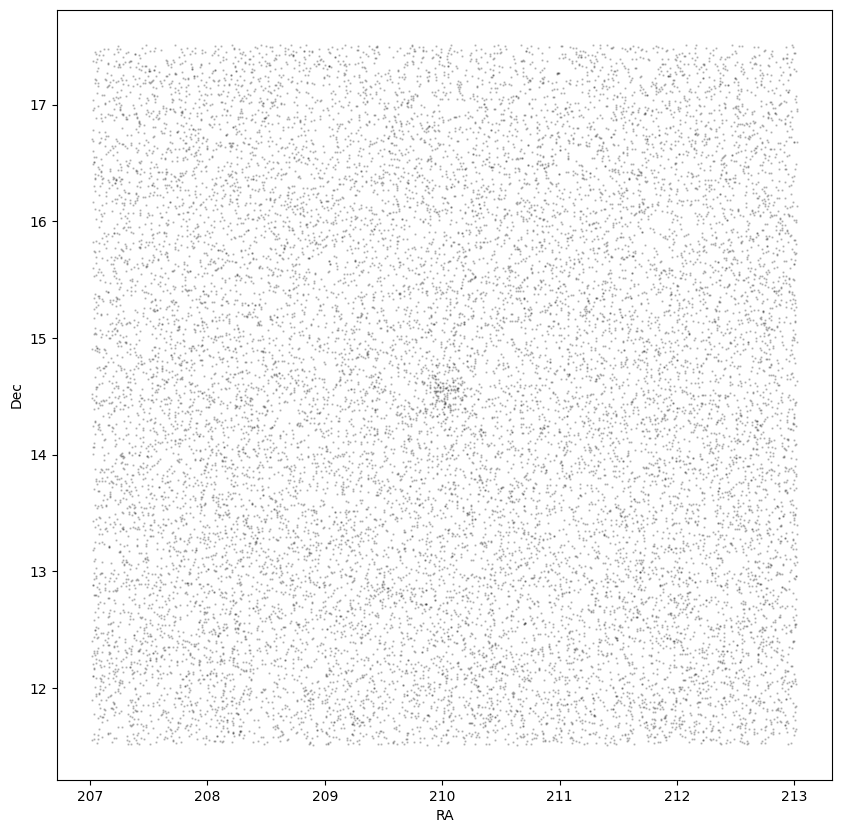

In [91]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

In [92]:
r['abs_Mg'] = r['phot_g_mean_mag'] + 5 + 5 * np.log10(r['parallax']/1000)

/tmp/ipykernel_280097/3489978312.py:1: RuntimeWarning: invalid value encountered in log10
  r['abs_Mg'] = r['phot_g_mean_mag'] + 5 + 5 * np.log10(r['parallax']/1000)


In [93]:
r['bp_rp'] = r['phot_bp_mean_mag']-r['phot_rp_mean_mag']

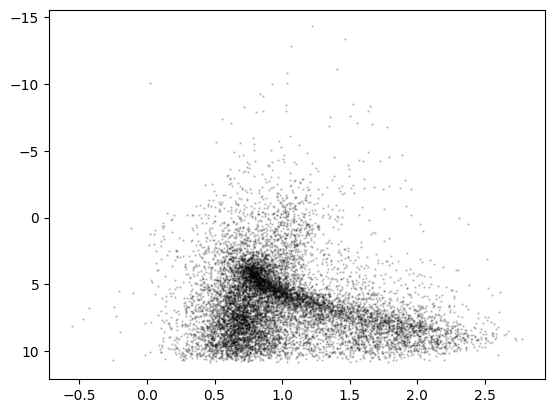

In [94]:
plt.scatter(r['bp_rp'], r['abs_Mg'], s=.5, alpha=.2, c='k', rasterized=True)
plt.gca().invert_yaxis()

In [ ]:
## Could use EagleEye to see if the candidates clusters in HR but that's a bit iffy.

## Ideally : we'd like the candidates list of that dwarf galaxy.

In [38]:
!cat candidate_2.csv

,source_id,dec,ra,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,phot_g_mean_mag,g_rp,bp_g,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error
351,3.6947E+18,-1.778258004,185.9115631,-1.856841925,-1.587827104,0.650408555,0.346071734,0.36419386,0.334638311,18.7071,0.5856304,0.27560043,0.86123085,620.163923,1.358747087,18.9827,352.7566366,11.81390606,18.12147,453.0854003,6.235874827
2048,3.69469E+18,-1.820663131,186.0652481,-2.359703295,-1.639412553,0.252294596,0.144183668,-0.340063754,0.134653119,17.112202,0.38694,0.16773033,0.55467033,2694.421252,40.11214702,17.279932,1692.710689,88.12081413,16.725262,1639.318047,57.70246222
2703,3.6947E+18,-1.757881038,185.9767798,-1.83971638,-1.458792987,0.231412667,0.136968008,-0.028395952,0.12304264,16.89397,0.6572342,0.48350906,1.1407433,3294.261366,2.935274966,17.37748,1547.260737,7.914949234,16.236736,2570.830282,8.658994556

### Retrieve GaiaDR3 info from GaiaDR2 source_id : 



In [ ]:
## TODO finish this later

# "SELECT dr2.source_id, dr3.source_id, dr3.ra, dr3.dec, dr3.pmra, dr3.pmdec, dr3.phot_g_mean_mag, dr3.phot_bp_mean_mag, \
#        dr3.phot_rp_mean_mag, dr3.parallax \
#     FROM gaiadr2.gaia_source AS dr2 \
# JOIN gaiadr3.dr2_neighbourhood AS dr3_match ON dr2.source_id = dr3_match.dr2_source_id \
# JOIN gaiadr3.gaia_source AS dr3 ON dr3_match.dr3_source_id = dr3.source_id \
# WHERE dr2.phot_g_mean_mag IN {}

## Catalog of stars of dwarf galaxy

In [66]:
import requests
from astropy.table import Table
from astroquery.vizier import Vizier
import io

In [67]:
v = Vizier(columns=["**"], row_limit=-1)  # fetch all rows

catalog_id = "J/A+A/657/A54"

# List available tables in this catalog
catalogs = v.find_catalogs(catalog_id)
print(f"Battaglia+2022 catalog tables:")
result = v.get_catalogs(catalog_id)
for i, t in enumerate(result):
    print(f"  Table {i}: {t.meta.get('name','?')} — {len(t)} rows, cols: {t.colnames[:5]}...")


Battaglia+2022 catalog tables:
  Table 0: J/A+A/657/A54/pmem — 645720 rows, cols: ['recno', 'Galaxy', 'GaiaEDR3', 'RA_ICRS', 'DE_ICRS']...


In [71]:
bata_tab = result[0]
galaxies = np.unique(bata_tab['Galaxy'])
print(galaxies)

     Galaxy    
---------------
       AntliaII
     AquariusII
        BootesI
       BootesII
      BootesIII
       BootesIV
 CanesVenaticiI
CanesVenaticiII
         Carina
       CarinaII
            ...
      TucanaIII
       TucanaIV
        TucanaV
        UGC4879
     UrsaMajorI
    UrsaMajorII
      UrsaMinor
         VirgoI
            WLM
       Willman1
Length = 74 rows


In [76]:
bata_tab[(bata_tab['Galaxy']=='BootesI') & (bata_tab['Pmemb']>0.5)]

recno,Galaxy,GaiaEDR3,RA_ICRS,DE_ICRS,Pmemb,_RA.icrs,_DE.icrs
,,,deg,deg,,deg,deg
int32,str15,int64,float64,float64,float64,float64,float64
401775,BootesI,1229890376568407296,210.179687544600795945,13.55215129590256673,0.7393096075095781,210.179687544600795945,13.55215129590256673
401786,BootesI,1229895702327886464,210.071176542540143828,13.65909905894794818,0.7424577996596717,210.071176542540143828,13.65909905894794818
402008,BootesI,1230625949847034752,209.702840741797018609,13.66716562097590071,0.916221704878484,209.702840741796990187,13.66716562097590071
402044,BootesI,1230649834160653440,209.802836698510162705,13.71546992582648627,0.9266491808247846,209.802836698510134283,13.71546992582648627
402046,BootesI,1230651341693932544,209.925654066314905322,13.80314937728803670,0.9739070915532593,209.925654066314905322,13.80314937728803848
402049,BootesI,1230651925809484928,209.857078518776859255,13.80259541458944383,0.9918796722708889,209.857078518776859255,13.80259541458944561
402068,BootesI,1230659588031211136,210.055920754676435536,13.91323379984299358,0.924012068125926,210.055920754676435536,13.91323379984299180
402072,BootesI,1230661065502765696,210.080959610202882004,13.99395217309763240,0.986943961968598,210.080959610202853582,13.99395217309763062


In [73]:
# # The summary table listing all galaxies
# zenodo_record = "6533296"
# base_url = f"https://zenodo.org/record/6533296{zenodo_record}/files"

# # First, get the file list from Zenodo API
# api_url = f"https://zenodo.org/api/records/{zenodo_record}"
# resp = requests.get(api_url)
# resp.raise_for_status()
# record = resp.json()

# files = {f['key']: f['links']['self'] for f in record['files']}
# print(f"Available files in Pace+2022 Zenodo record ({len(files)} files):")
# for fname in sorted(files.keys())[:10]:
#     print(f"  {fname}")
# if len(files) > 10:
#     print(f"  ... and {len(files)-10} more")


Available files in Pace+2022 Zenodo record (1 files):
  catalog.zip


In [104]:
# files

## Let's use Battaglia's Table for now.... what do we want to do/know?

In [142]:
r

source_id,ra,dec,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,parallax
,deg,deg,mas / yr,mas / yr,mag,mag,mag,mas
int64,float64,float64,float64,float64,float32,float32,float32,float64
1226166193245799040,212.54978320215923,11.53515126032221,-0.6919167631492058,-0.6770731837098172,18.938671,19.242632,18.531094,0.1583832934107342
1226166468123710464,212.53740671841473,11.54804815231049,-3.0338735685797573,-4.349182950398391,20.691904,21.202856,20.067785,-0.015242869335718764
1226209628250198400,211.98464624133138,11.644799933807914,-1.6888582450895515,-4.505905061501474,20.407578,--,--,0.6780689541221531
1226220795165578112,212.4474446561607,11.638894670138983,-2.3241127700089024,-0.959351619032109,15.355655,15.685377,14.853966,0.3873870354291092
1226268555202011392,212.8028250443634,11.704465269855843,-2.1339356115783223,-4.7346863451324355,19.980366,20.331696,19.485395,0.593714096319752
1226278515230978560,212.9243653317238,11.909672474343258,-3.837371399023854,-4.816022733982764,17.566074,17.969938,16.998306,0.5232292328598658
1226317547893702912,212.61836640466453,11.795795193516161,-4.808007763745461,-2.1068189745785406,19.314726,19.611828,18.861544,0.21288506070181237
1226319819931637504,212.73488127007732,11.882294550865813,-1.2581190405557883,-1.0751354616052122,19.327496,19.758066,18.791658,0.46865908904404713


In [82]:
boote_bat = bata_tab[(bata_tab['Galaxy']=='BootesI') & (bata_tab['Pmemb']>0.5)]

#### We could rerun a query to make sure we're not losing additional candidates from our og cut, just querying those source_id

but i'm not doing it here, just crossing with our table

In [98]:
boote_r = r[np.isin(r['source_id'], boote_bat['GaiaEDR3'])]

Text(0, 0.5, 'Dec')

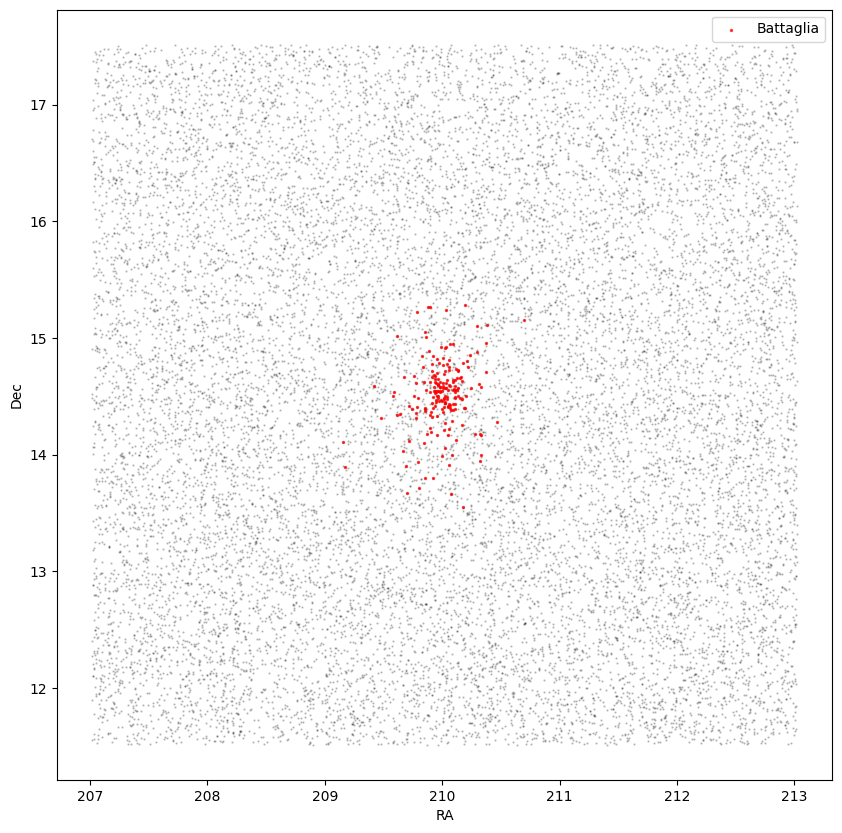

In [100]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)

plt.scatter(boote_r['ra'], boote_r['dec'], s=2, alpha=.7, c='r', label='Battaglia', rasterized=True)
plt.legend()
plt.xlabel('RA')
plt.ylabel('Dec')

Text(0, 0.5, 'M_g')

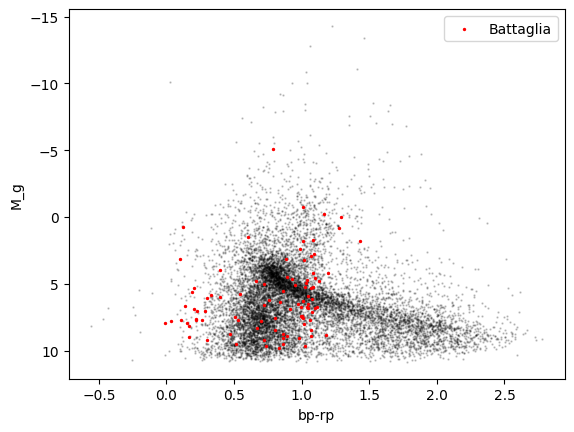

In [103]:
## HR Diagram: doesnt look like it's clustering there which I think make sense?...?

plt.scatter(r['bp_rp'], r['abs_Mg'], s=.5, alpha=.2, c='k', rasterized=True)
plt.scatter(boote_r['bp_rp'], boote_r['abs_Mg'], s=2, alpha=1, c='r', label='Battaglia', rasterized=True)
plt.legend()
plt.gca().invert_yaxis()
plt.xlabel('bp-rp')
plt.ylabel('M_g')

In [143]:
gaia = r

### Looking at the spectra

In [147]:
# id_list = ", ".join(str(sid) for sid in gaia['source_id'][:10])

# #xp_summary
# query = f"""
#     SELECT
#         *
#     FROM gaiadr3.xp_continuous_mean_spectrum
#     WHERE source_id IN ({id_list})
# """
# print(query)

# job = Gaia.launch_job_async(query)

# r = job.get_results()
# r

In [148]:
# r = r.to_pandas()
# r

In [ ]:

from gaiaxpy import convert



In [122]:
# query_input = [1226166193245799040, 1226166468123710464, 1226209628250198400, 1226220795165578112, 1226268555202011392]
# converted_spectra, sampling = convert(query_input)
# converted_spectra

In [ ]:
t = time.time()
# We need to do it in chunks
converted_spectra, sampling = convert(list(gaia['source_id'][:100].data.data))

print(time.time()-t)
converted_spectra

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
Running query...